In [1]:
from fourier_paper_reproduction_2023_09_28 import default_config, output_dir
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from misc_utils import read_jsonl_to_df, keep_serializable

from itertools import product
from pathlib import Path

import fire
import jsonlines
import numpy as np
from loguru import logger

from fourier_paper_reproduction import (
    accuracy,
    get_ipr,
    how_many_terms_to_achieve,
    how_many_terms_to_achieve_relative_weight,
    rel_fourier_weight_in_largest_terms,
    sign_overlap,
)
from fourier_supervised_cleanroom import (
    amplitude_median_bin_signal,
    amplitude_prob_median_bin_signal,
    fit_fourier_series,
    ground_state_signal,
    sign_signal,
)
from fourier_supervised_cleanroom_2023_09_27 import get_lattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from spin_lattices import KagomeLattice, SquareLattice, TriangularLattice
from misc_utils import convert_column_to as to

In [2]:
df = read_jsonl_to_df(output_dir.glob('*/results.jsonl')).fillna(keep_serializable(default_config))

In [3]:
df['threshold'].unique()

array([0.02, 0.2 , 0.5 , 0.8 , 0.9 , 0.95, 0.99])

In [ ]:
pd.Series.rank()

In [20]:
(
    df.query('scorer == "accuracy" and signal == "sign_signal"')
    .melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "iipr"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold"],
    )
    .query(
        '(threshold == 0.8 and variable == "terms_score_threshold") '
        'or (threshold == 0.2 and variable == "terms_relweight_threshold")'
    )
    .drop(columns=["threshold"])
    .pivot_table(values="value", index=["J2", "lattice", "n_spins", "iipr"], columns="variable")
    .reset_index()
    .melt(
        id_vars=["J2", "lattice", "n_spins"],
        value_vars=["iipr", "terms_score_threshold", "terms_relweight_threshold"],
    )
    .sort_values("n_spins")
    .assign(
        lattice_name=lambda df: df.lattice.str.replace(r"Lattice.+", "Lattice", regex=True),
        spins_order=lambda df: df.groupby("lattice_name")['n_spins'].transform(
            lambda x: x.rank(method="dense")
        ),
    )
)

,J2,lattice,n_spins,variable,value,lattice_name,spins_order
0,0.00,KagomeLattice2x2,12,iipr,9.776161,KagomeLattice,1.0
209,0.65,KagomeLattice2x2,12,iipr,189.791264,KagomeLattice,1.0
720,1.40,TriangularLattice4x3,12,terms_score_threshold,17.000000,TriangularLattice,1.0
213,0.65,SquareLattice4x3,12,iipr,9.776161,SquareLattice,1.0
715,1.35,TriangularLattice4x3,12,terms_score_threshold,17.000000,TriangularLattice,1.0
...,...,...,...,...,...,...,...
803,0.20,SquareLattice7x4,28,terms_relweight_threshold,2281.000000,SquareLattice,6.0
610,0.75,SquareLattice7x4,28,terms_score_threshold,1.000000,SquareLattice,6.0
79,0.20,SquareLattice7x4,28,iipr,8844.793042,SquareLattice,6.0
777,0.15,TriangularLattice7x4,28,terms_relweight_threshold,2365.000000,TriangularLattice,6.0


In [25]:
df.to_csv("fourier_paper_reproduction_df.csv", index=False)

/tmp/nix-shell.5n1UNd/ipykernel_586863/4285113721.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


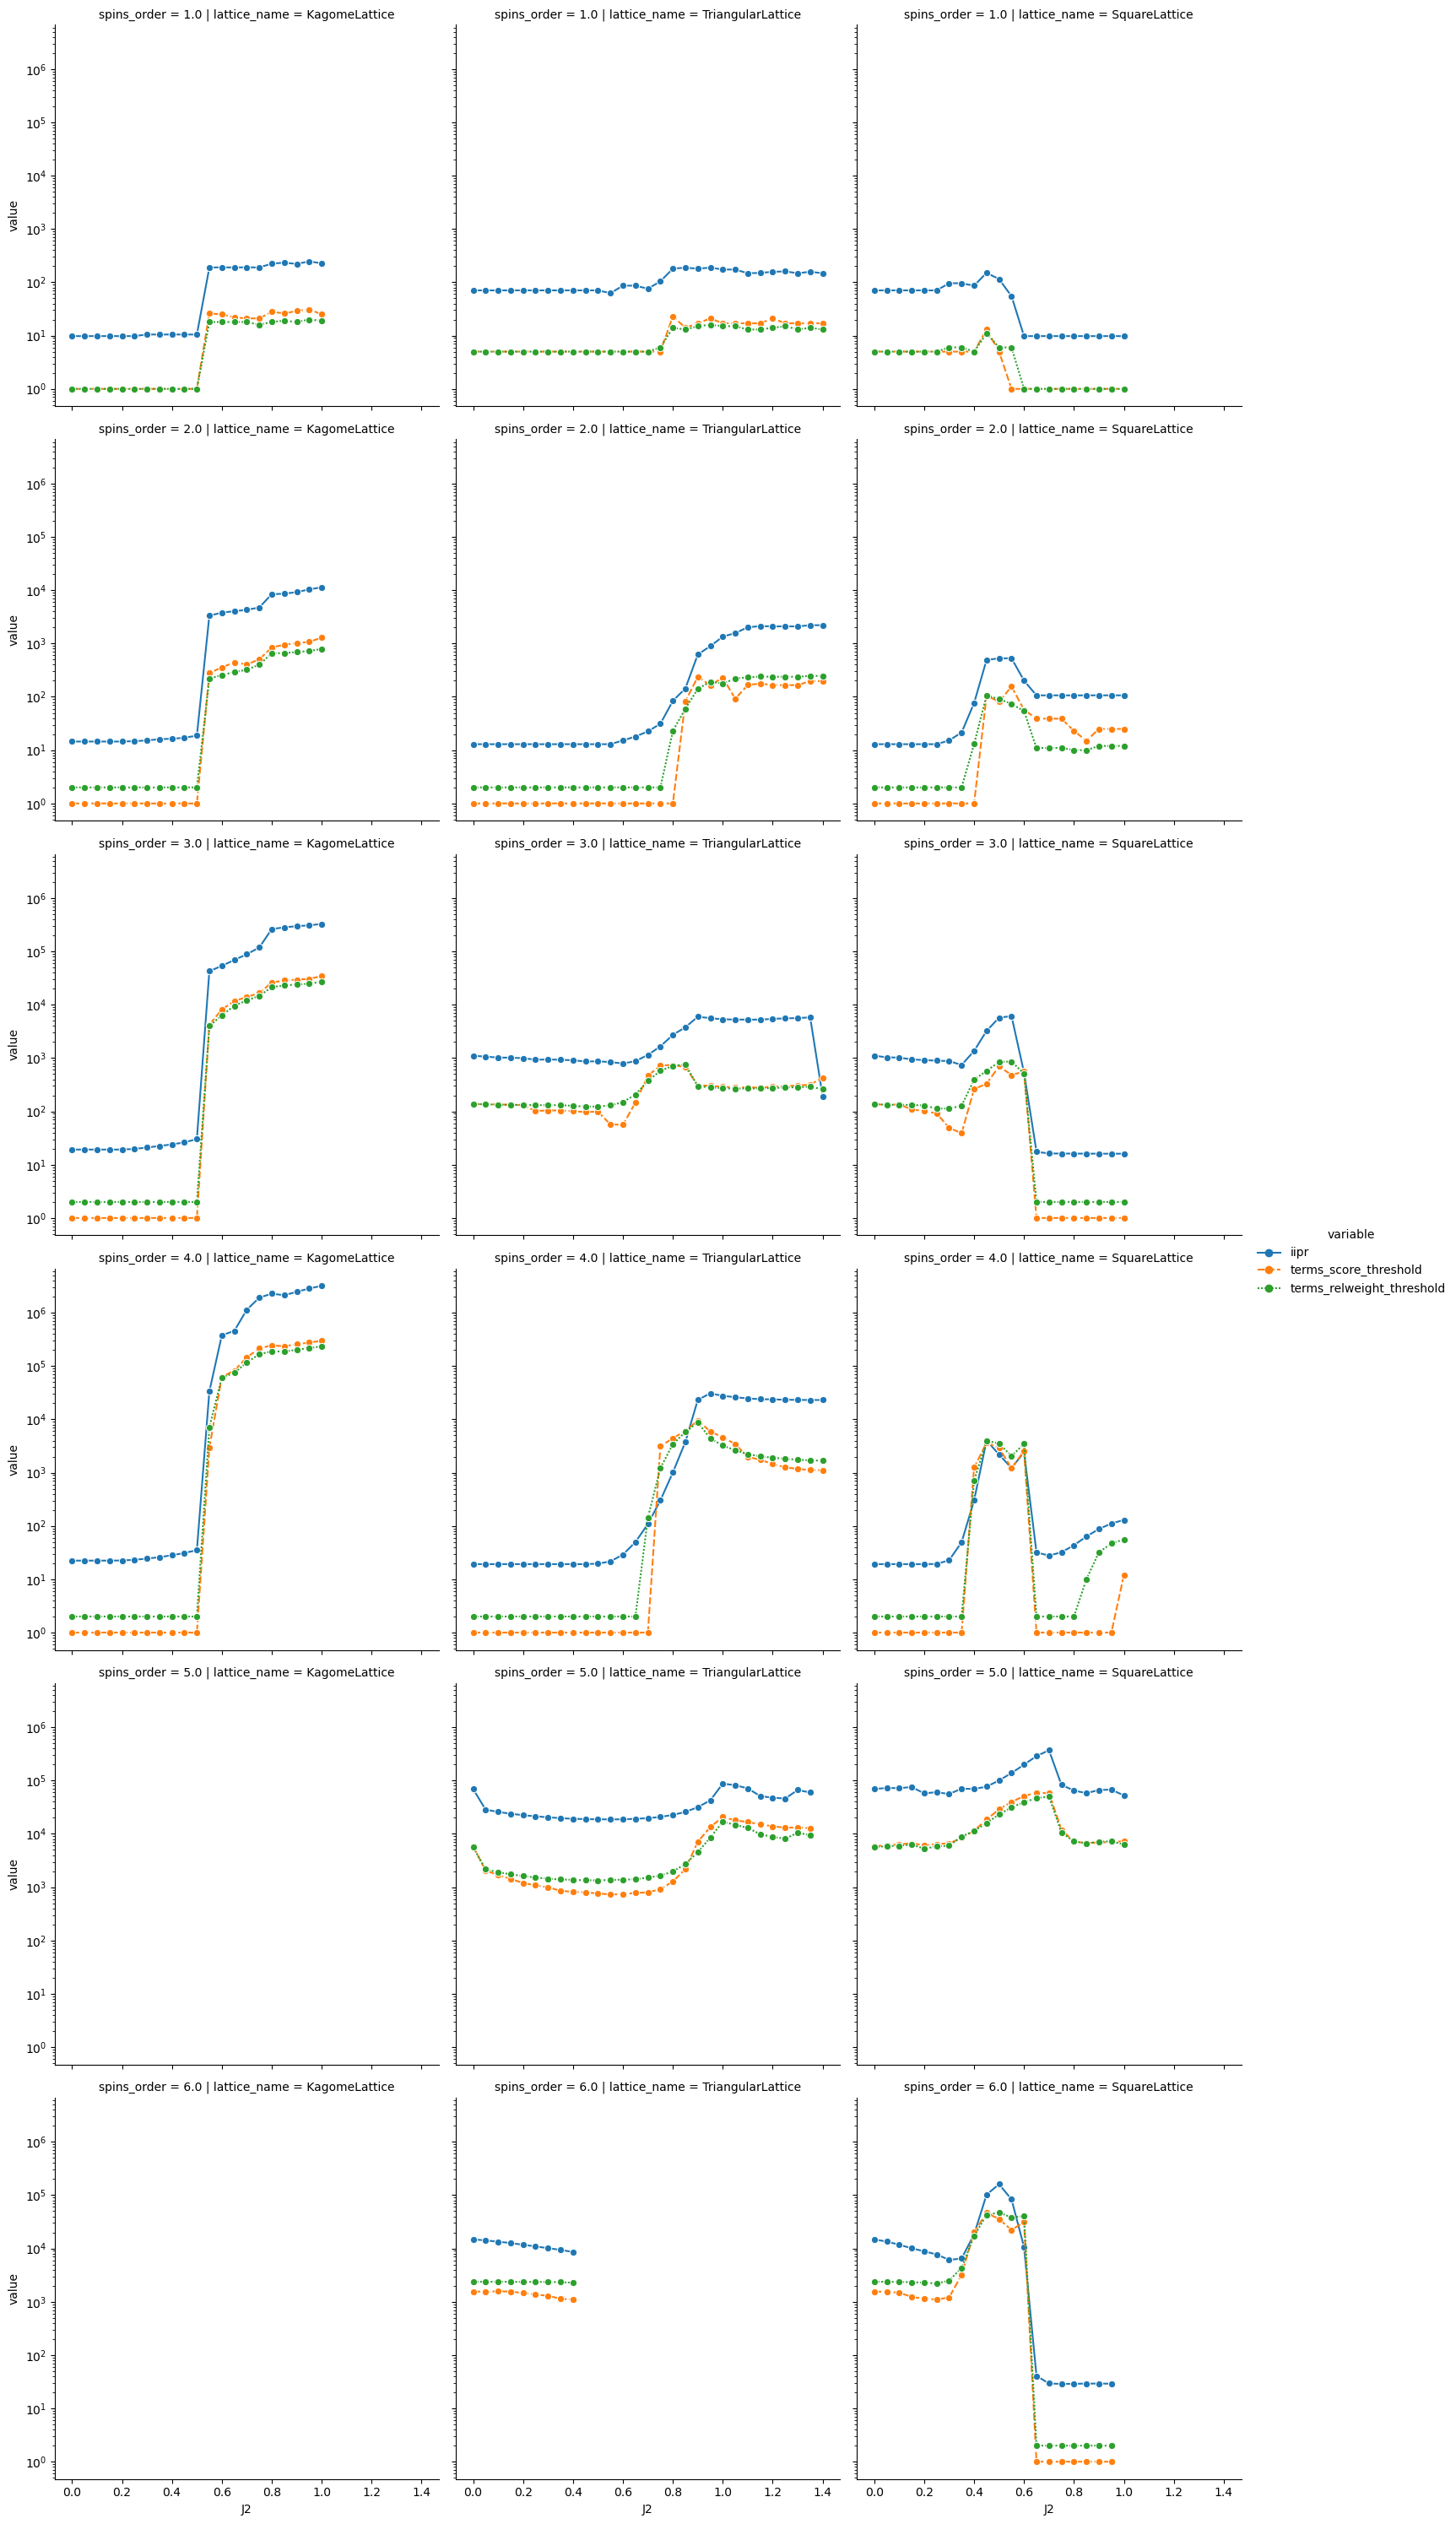

In [24]:
sns.relplot(
    df.query('scorer == "accuracy" and signal == "sign_signal"')
    .melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "iipr"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold"],
    )
    .query(
        '(threshold == 0.8 and variable == "terms_score_threshold") '
        'or (threshold == 0.2 and variable == "terms_relweight_threshold")'
    )
    .drop(columns=["threshold"])
    .pivot_table(values="value", index=["J2", "lattice", "n_spins", "iipr"], columns="variable")
    .reset_index()
    .melt(
        id_vars=["J2", "lattice", "n_spins"],
        value_vars=["iipr", "terms_score_threshold", "terms_relweight_threshold"],
    )
    .sort_values("n_spins")
    .assign(
        lattice_name=lambda df: df.lattice.str.replace(r"Lattice.+", "Lattice", regex=True),
        spins_order=lambda df: df.groupby("lattice_name")['n_spins'].transform(
            lambda x: x.rank(method="dense")
        ),
    ),
    x="J2",
    y="value",
    hue="variable",
    col="lattice_name",
    row='spins_order',
    kind="line",
    markers=["o"],
    style="variable",
).set(yscale="log")

/tmp/nix-shell.5n1UNd/ipykernel_586863/2755644392.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


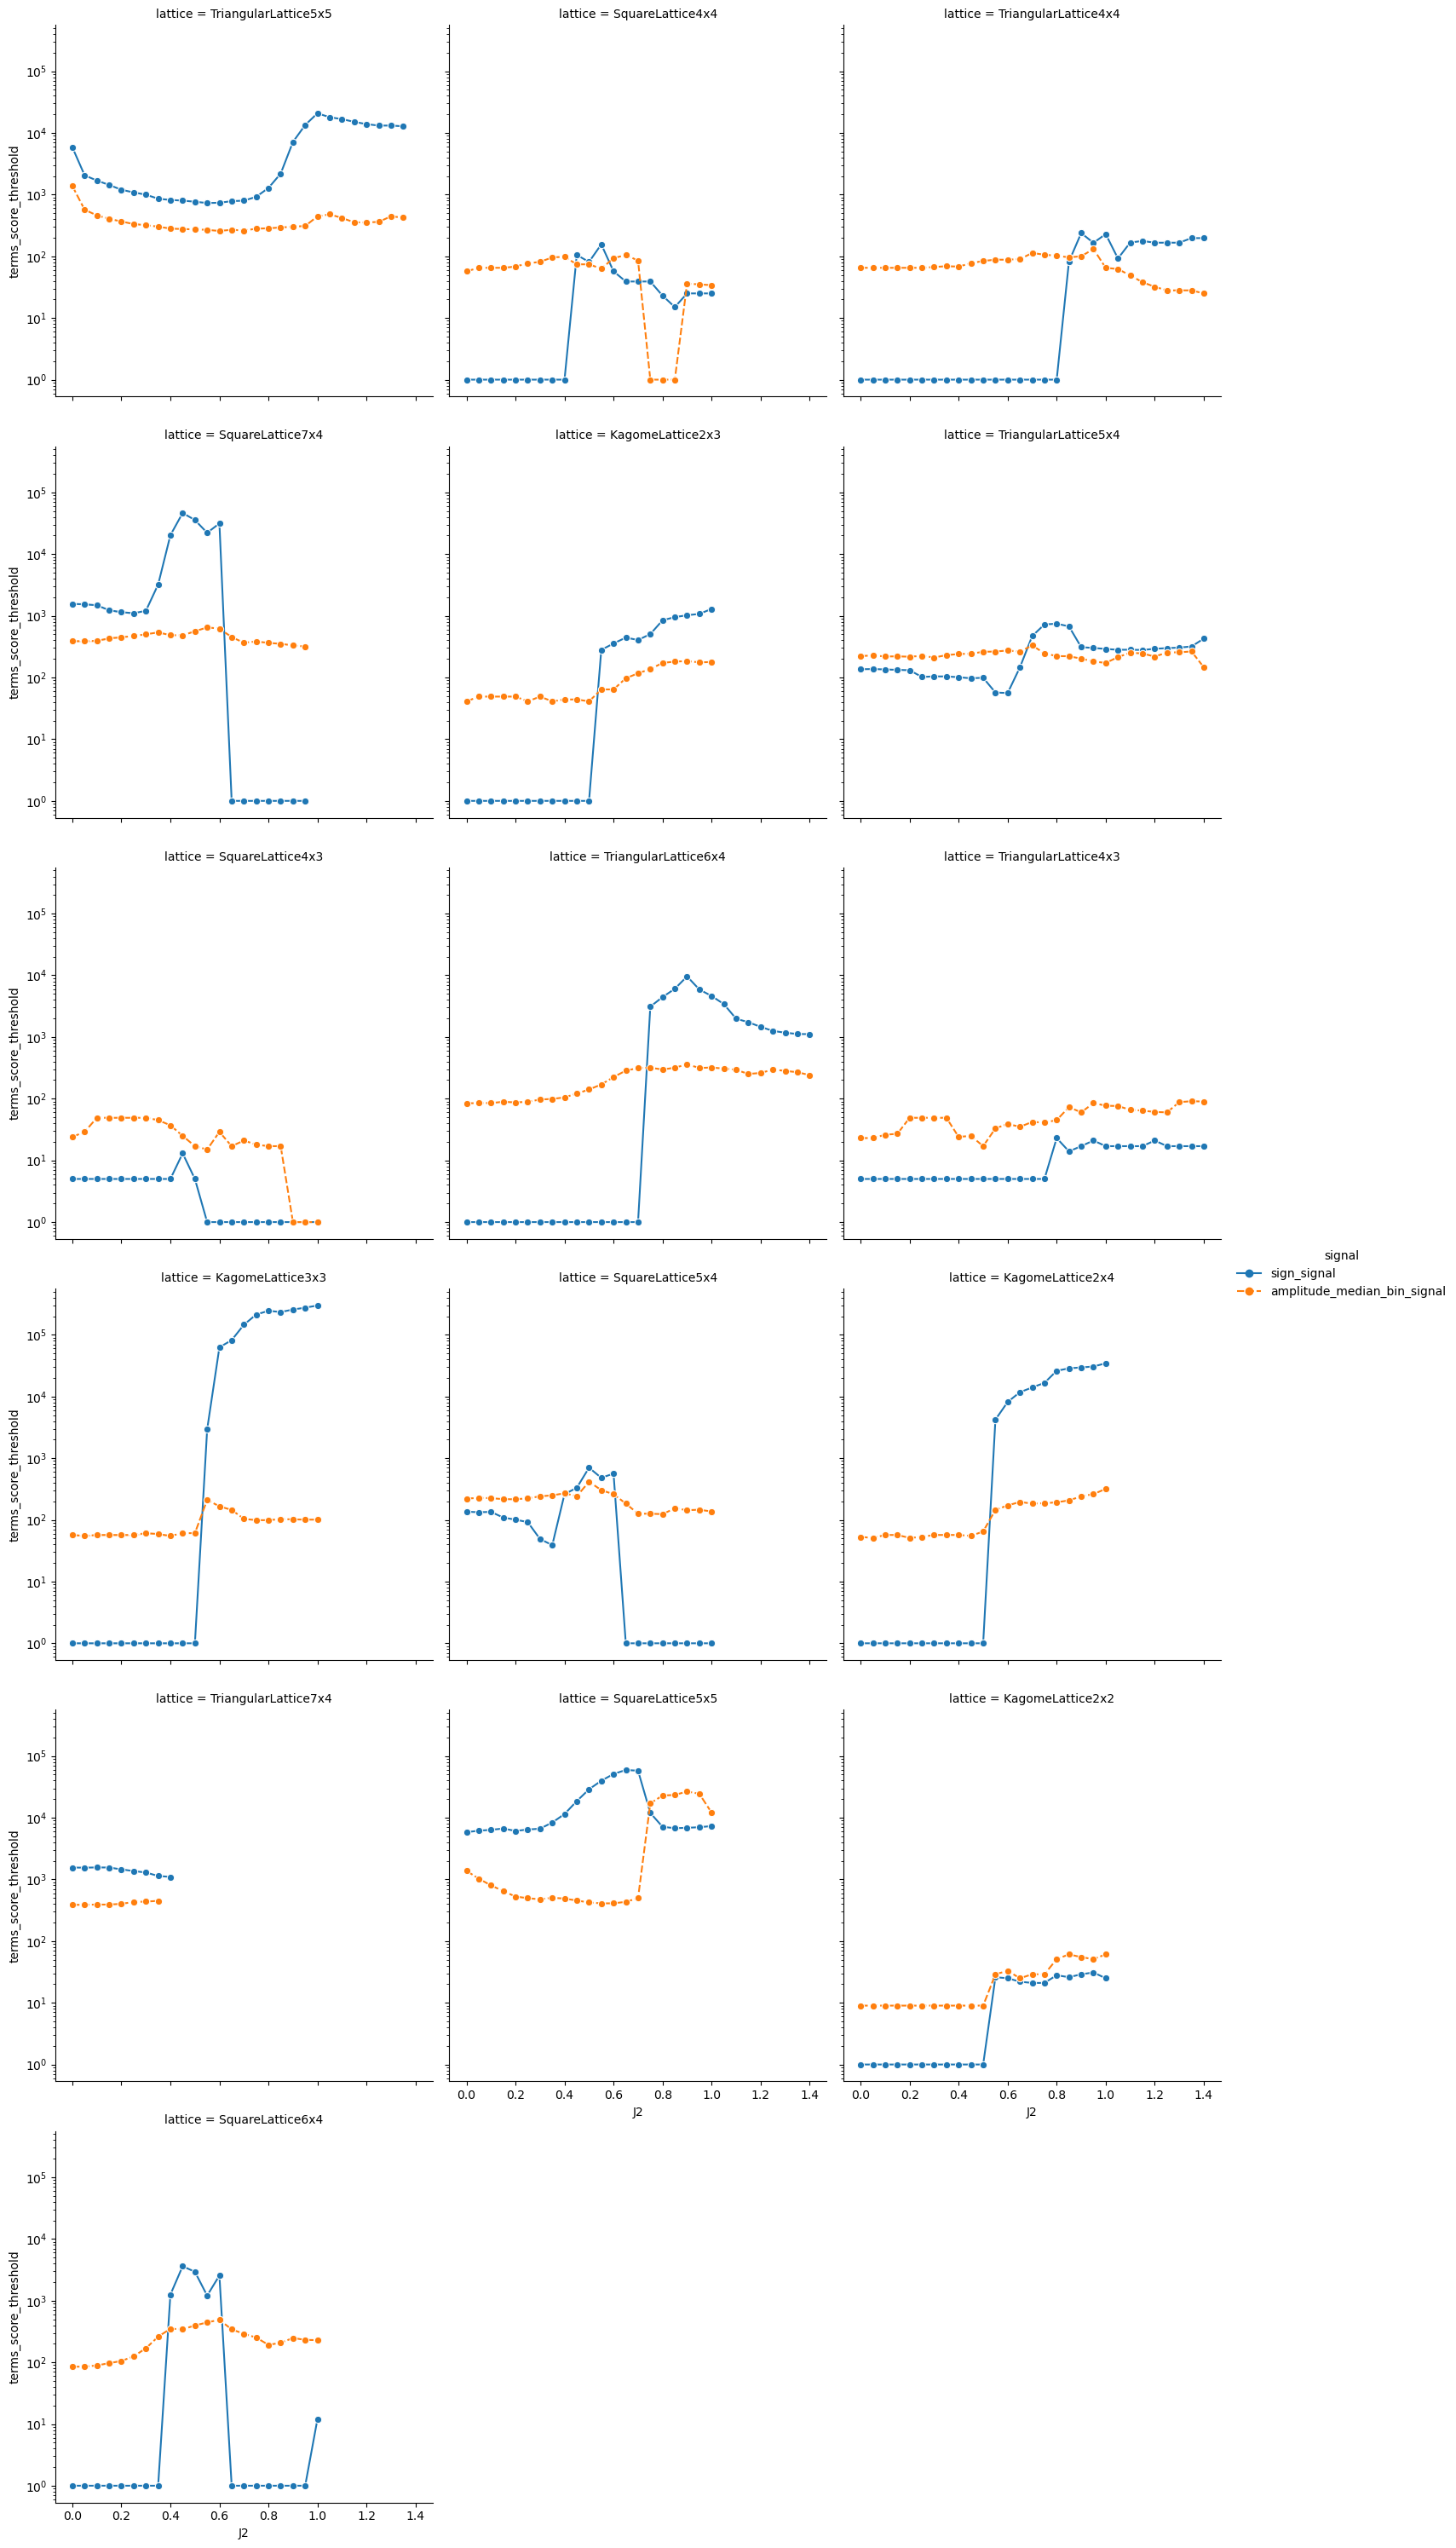

In [5]:
sns.relplot(
    df.query('scorer == "accuracy" and '
             'threshold == 0.8 and '
             '(signal == "sign_signal" or signal == "amplitude_median_bin_signal")'),
    x="J2",
    y="terms_score_threshold",
    hue="signal",
    col="lattice",
    col_wrap=3,
    kind="line",
    markers=["o"],
    style="signal",
).set(yscale="log")

/tmp/nix-shell.5n1UNd/ipykernel_586863/2442400427.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


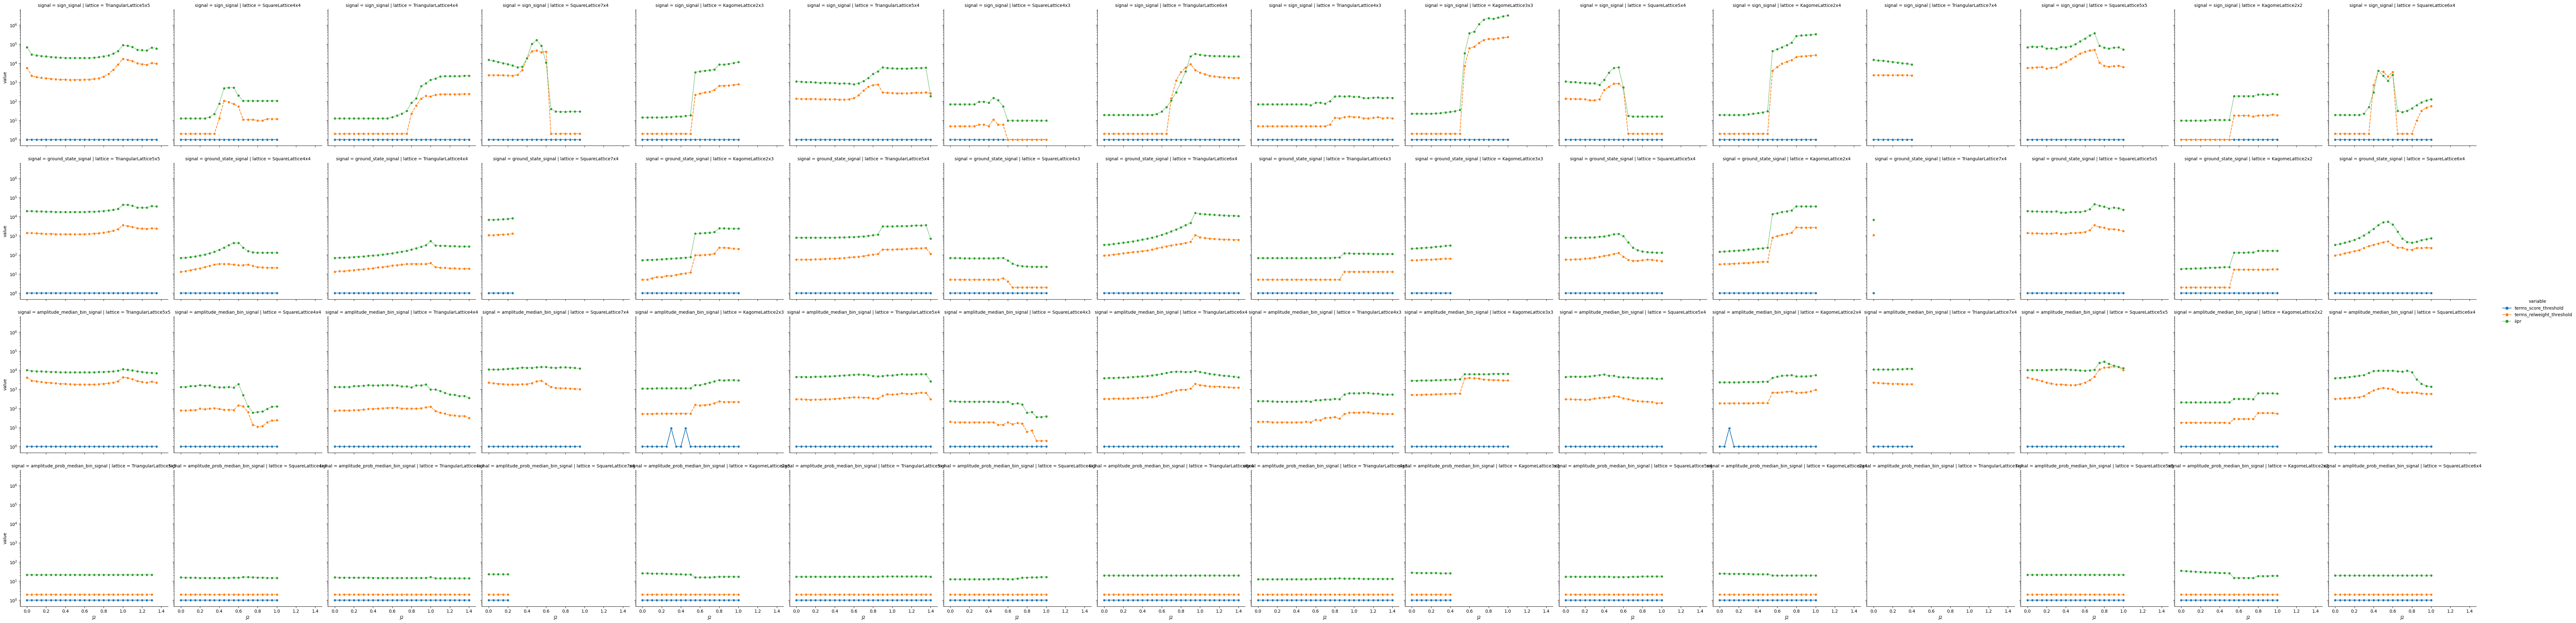

In [6]:
sns.relplot(
    df.query('threshold == 0.2 and scorer == "accuracy"').melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "scorer", "signal"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold", "iipr"],
    ),
    x="J2",
    y="value",
    hue="variable",
    col="lattice",
    row="signal",
    kind="line",
    markers=["o"],
    style="variable",
).set(yscale="log")